# RAPID-MFA-20: Monte Carlo 

## Descriptions
This is a RAPID MFA Monte Carlo analysis. In Monte Carlo simulations we change every input parameter by a randomized %. By running many (hundreds to thousands of) iterations, this gives us the option to capture the uncertainties' effects comprehensively, and communicate and assess the variances of this big range of results. 

The data and code below are the flow-driven dynamic MFA model from _Accounting for the Material Stock of Nations_ (Fishman et al. 2014). This study explores the flows and stocks of four EW-MFA material groups (timber, nonmetallic minerals, iron, and other metals) in Japan and the United States. This example only uses the iron flows from Japan.

### Exogenous variables
__Inflows:__ Iron inflows, Japan from _Accounting for the Material Stock of Nations_ (Fishman et al. 2014)

__Survival curve:__ Fixed mean and standard deviation of iron. 


### Relations with other RAPID-MFA codes
- The concept of a flow driven model, explained in  `RAPID-MFA-1: The_flow_driven_model`. The inputus however are different.

- The code below is a basic implementation that prioritizes similarity to the dynamic MFA model equations. For faster and more efficient code implementations, check `RAPID-MFA-18_speeding_up_the_flow_driven_model_with_convolution` and `RAPID-MFA-19_speeding_up_the_stock_driven_model_with_convolution`


## Licence and how to cite
Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Define example input data

In [2]:
# %% 2. Define example input data
# timeframes
input_data = pd.Series([5.368053963, 4.599245144, 7.778141396, 10.40946094, 8.612509432, 
                        9.294833307, 6.872771035, 6.131480153, 7.675508564, 7.656760079, 
                        22.36252695, 13.26566029, 11.57560672, 14.24030449, 15.5685982, 
                        24.43131036, 42.7792729, 44.40791736, 52.61167105, 54.0044283, 
                        73.46850832, 37.86125762, 58.92838997, 135.0291435, 100.6286295, 
                        108.3565278, 131.2462731, 275.825282, 265.5538642, 271.9214933, 
                        318.6953652, 326.4563373, 476.5492788, 498.8840475, 635.5669994, 
                        801.8130779, 724.9835985, 767.8567933, 839.4157856, 838.1205998, 
                        1074.986997, 1438.628104, 1520.676671, 1104.51503, 1406.702202, 
                        1639.535553, 1960.551947, 1934.782522, 2001.642926, 2537.560937, 
                        3616.139069, 4304.422416, 4080.048109, 3269.937006, 3777.529008, 
                        4651.528793, 1524.425, 1860.658, 2375.616, 2544.14, 2963.854, 
                        2921.764, 3031.046, 3455.525, 3950.27, 4394.143, 4745.475, 2335.772, 
                        1058.163, 1376.133, 2202.474, 3890.472, 4281.006, 6601.591, 8790.017, 
                        8322.582, 9346.699, 9762.278, 12973.309, 15083.617, 13061.982, 
                        16399.014, 21582.001, 28040.996, 30478.46654, 33467.24176, 39899.90487, 
                        41529.31669, 49219.66214, 67345.10531, 70343.66735, 81169.16776, 
                        99478.49338, 100022.4938, 97569.72846, 120035.2762, 117325.1142, 
                        107524.1067, 100916.0215, 101258.772, 88670.81072, 105325.7562, 
                        109841.3529, 101131.7817, 98431.90713, 85623.35019, 102211.4884, 
                        98970.74956, 92814.95999, 95673.05432, 114501.5443, 120297.8667, 
                        122051.1472, 125109.1653, 103498.3784, 101174.942, 102470.2093, 
                        110436.7953, 106498.5484, 111751.7779, 97191.76952, 95048.03814, 
                        108624.3669, 96888.54608, 92999.7933, 98879.84507, 101041.9843, 
                        101680.7382, 101843.3801, 101837.002, 101799.5306, 101730.1686, 
                        101629.7132, 101498.9618, 101337.9144, 101144.9763, 100921.7422, 
                        100667.4148, 100382.7914, 100067.0746, 99721.85899, 99347.94188, 
                        98946.12051, 98517.98941, 98065.1431, 97589.97339, 97094.07479, 
                        96577.44732, 96043.28002, 95490.77564, 94923.12322, 94339.52552, 
                        93742.37432, 93130.87235, 92508.20868, 91872.78878, 91227.00443, 
                        90570.85565, 89905.93695, 89232.24835, 88550.5871, 87864.14226, 
                        87171.3193, 86475.30728, 85776.90347, 85077.7024, 84378.50133, 
                        83680.89478, 82984.88277, 82288.07349, 81591.26421, 80895.25219, 
                        80199.24018
                       ], 
                        name = 'inflows',
                        index = [1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 
                                 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 
                                 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 
                                 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 
                                 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 
                                 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 
                                 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 
                                 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 
                                 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 
                                 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 
                                 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 
                                 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 
                                 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 
                                 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 
                                 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 
                                 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 
                                 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 
                                 2048, 2049, 2050

                         ]
)  # Iron inflows per year in Japan

#Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 50
std_dev = 16.66666667 


## 3. Flow driven model as function

The flow driven model is written in a Function to be able to call and run the same inflow driven DMFA model as often as required. The Function needs the input data, ages, mean and the standard deviation as defined earlier and returns the full DMFA system.

In [3]:
# %% 3. Flow driven MFA in function
def flow_driven_model(input_data, ages, mean, std_dev):

    survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev) 
    mfa_system = {}
    timeframes = cohorts = input_data.index  

    time_interval = 1 # Interval between timeframes, usually 1, e.g. from 2005 to 2006 but can be different, e.g. 2005 to 2010. In which case time_interval = 5

    cohort_stop = (cohorts[-1] + time_interval)

    survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

    mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])    
    mfa_system['inflows'] = input_data

    # and populate that matrix
    for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
        survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
    
    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

    # And populate it
    for cohort in cohorts:
        # scale the shifted survival curve with the inflow of the time-th timeframe
        cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system['inflows'].loc[cohort]

    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis='columns')
    mfa_system["stocks"]

    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
    mfa_system["stock_changes"]

    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]
    mfa_system["outflows"]

    return mfa_system

## 4. View the full MFA system

In [4]:
#Call function to show the original run
mfa_system = flow_driven_model(input_data, ages, mean, std_dev)

In [5]:
# Set up the MFA system
units = {'time_interval': 'year', 
         'flows':         'kg/year', 
         'stocks':        'kg'}

# Add units to the MFA system
mfa_system_with_units = mfa_system.rename(columns={"stocks" : 'stocks [' + units['stocks'] + ']', 
                                                   "inflows" : 'inflows [' + units['flows'] + ']', 
                                                   "outflows" : 'outflows [' + units['flows'] + ']', 
                                                   "stock_changes" : 'stock_changes [' + units['flows'] + ']'})

<Axes: ylabel='kg/year'>

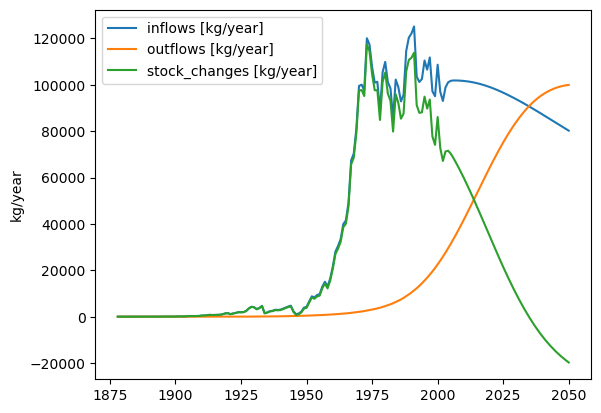

In [6]:
#plot the original run
mfa_system_with_units[["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]].plot(ylabel=units['flows'])

## 5. Monte Carlo

Be careful! according increasing the number of runs might substantially increase the run time, using this data format. If you want to speed up things please refer to 
`RAPID-MFA-18: speeding_up_the_flow_driven_model_with_convolution` or `RAPID-MFA-19: speeding_up_the_stock_driven_model_with_deconvolution` for the stock driven model. If you want to run the model with a convolution, replace the basic flow driven model with the code from the convolution.

In [7]:
#Set up number of runs
runs = 200

Here we choose a random seed, which enables us to reproduce the same 'random' sequence as in the example. The reason is that the chosen number from python are not actually random but follow a selection logic. A random seed thus allows us to reproduce the same sequence by setting the same starting point in python. We use this to examplify the monte carlo simulation and for transparancy of the underlying code, however a random seed is not required to run the monte carlo simulation.

In [8]:
# Choose a random seed
random_seed = 42

#### Set up the randomization of the input values for the runs

We create a dataframe with random percent change coefficients for the four input variables.

We pre-compute this as a lookup table, because calling the scipy random method (`uniform.rvs`) once for an entire array is much faster than calling it at again and again hundreds or thousands of times for individual numbers.

Our randomizations will be confined to certain ranges:
- inflows will be allowed to vary by a maximum of +/- 10%, with equal (uniform) probabilities of any value in between, because we're relatively confident about the original values
- means will be allowed to vary by a maximum of +/- 30%, with equal (uniform) probabilities of any value in between, because we're not so confident about the original values
- standard deviation will be allowed to vary by a maximum of +/- 30%, with equal (uniform) probabilities of any value in between, because we're not so confident about the original values
- percent to construction will be allowed to vary by a maximum of +/- 30%, with equal (uniform) probabilities of any value in between, because we're relatively confident about the original values

In [9]:
# Set up the randomization of the variables
randomize_vars = pd.DataFrame()
randomize_vars["inflows"] = scipy.stats.uniform.rvs(loc=0.9, scale=0.2, size=runs, random_state=random_seed)  # inflows will vary by a maximum of +/- 10%, with equal (uniform) probabilities of any value in between, because we're relatively confident about the original values
randomize_vars["mean"] = scipy.stats.uniform.rvs(loc=0.7, scale=0.6, size=runs, random_state=random_seed)  # mean will vary by a maximum of +/- 30%, with equal (uniform) probabilities of any value in between, because we're not so confident about the original values
randomize_vars["standard_deviation"] = scipy.stats.uniform.rvs(loc=0.7, scale=0.6, size=runs, random_state=random_seed)  # standard deviation will vary by a maximum of +/- 30%, with equal (uniform) probabilities of any value in between, because we're not so confident about the original values

In [10]:
#Run the monte carlo simulation
monte_carlo_results = {}

for row in randomize_vars.index:
    # vary the input parameters with this run's randomized change coefficients
    input_data_random = randomize_vars['inflows'][row] * input_data
    mean_random = randomize_vars['mean'][row] * mean
    std_dev_random = randomize_vars['standard_deviation'][row] * std_dev

    # run the flow-driven model with the randomized parameters
    mfa_system_random = flow_driven_model(input_data_random, ages, mean_random, std_dev_random)
    monte_carlo_results[row] = mfa_system_random

In [11]:
monte_carlo_results_df = pd.concat(monte_carlo_results.values(), keys=monte_carlo_results.keys(), axis=1)

monte_carlo_results_grouped = monte_carlo_results_df.T.groupby(level=1)

monte_carlo_statistics = monte_carlo_results_grouped.quantile(q=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).T

## 6. Visualisations

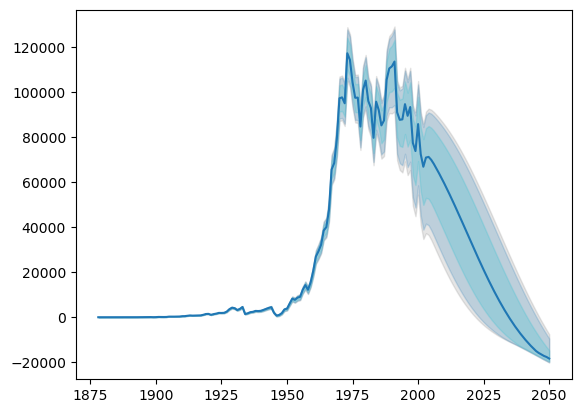

In [12]:
monte_carlo_stock_or_flow =  'stock_changes'

plt.fill_between(x=monte_carlo_statistics.index, 
                 y1=monte_carlo_statistics[monte_carlo_stock_or_flow, 0.05], 
                 y2=monte_carlo_statistics[monte_carlo_stock_or_flow , 0.95], 
                 alpha=0.2, color='tab:gray')
plt.fill_between(x=monte_carlo_statistics.index, 
                 y1=monte_carlo_statistics[monte_carlo_stock_or_flow, 0.1], 
                 y2=monte_carlo_statistics[monte_carlo_stock_or_flow, 0.9], 
                 alpha=0.2, color='tab:blue')
plt.fill_between(x=monte_carlo_statistics.index, 
                 y1=monte_carlo_statistics[monte_carlo_stock_or_flow, 0.25], 
                 y2=monte_carlo_statistics[monte_carlo_stock_or_flow, 0.75], 
                 alpha=0.2, color='tab:cyan')
plt.plot(monte_carlo_statistics[monte_carlo_stock_or_flow, 0.5])